# Comparing Embeddings Models

In this video, we'll explore different embedding models available in the Sentence Transformers ecosystem and understand their trade-offs.

Embedding models differ in many ways, including:
1. Size and computational requirements
2. Language support (monolingual vs. multilingual)
3. Context length limitations
4. Embedding dimensionality 
5. Performance on specific tasks

Sentence Transformers provides access to a wide range of pre-trained models optimized for different use cases. Some popular models include:

- all-MiniLM-L6-v2: A compact, efficient model that produces 384-dimensional embeddings
- all-mpnet-base-v2: A more powerful model with 768-dimensional embeddings
- paraphrase-multilingual-MiniLM-L12-v2: Supports 50+ languages
- multi-qa-mpnet-base-dot-v1: Optimized for question-answering tasks

When selecting an embedding model for your application, consider these factors:

1. Accuracy requirements: More powerful models typically produce better embeddings but require more computation
2. Inference speed: Smaller models are faster but may sacrifice some accuracy
3. Resource constraints: Model size affects memory usage and deployment options
4. Multilingual needs: Some models support multiple languages, while others are optimized for English
5. Specific tasks: Models fine-tuned for particular tasks often perform better on those tasks

Let's compare several embedding models to understand their trade-offs in a real-world production context.

In [1]:
# Install the required packages
!uv pip install accelerate==1.6.0 sentence-transformers==4.0.2

Using Python 3.12.13 environment at: /workspaces/fundamentals-of-ai-engineering-principles-and-practical-applications-6026542/.venv
Checked 2 packages in 631ms


In [2]:
# Imports
import random
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
import time
import pandas as pd

import numpy as np
import seaborn as sns

In [3]:
# Set a nice visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

In [4]:
# Different embeddings models
models = [
    'all-MiniLM-L6-v2',  # Small model (384d)
    'all-MiniLM-L12-v2',  # Medium model (384d)
    'all-mpnet-base-v2',  # Large model (768d)
    'paraphrase-multilingual-MiniLM-L12-v2'  # Multilingual model (384d)
]

In [5]:
# Example sentences for benchmarking, organized by topic pairs
sentence_pairs = [
    # Technology pairs (semantically similar)
    ["Machine learning models require significant computational resources.",
     "AI systems need a lot of computing power to train."],

    # Programming pairs (semantically similar)
    ["What's the best algorithm for text classification?",
     "How can I optimize my neural network training time?"],

    # Weather pairs (semantically similar)
    ["The weather forecast predicts rain tomorrow.",
     "It's going to be wet outside tomorrow according to meteorologists."],

    # Office pairs (semantically similar)
    ["I need to get a new computer for my office.",
     "My workplace needs updated computing equipment."],

    # Health pairs (semantically similar)
    ["Regular exercise improves cardiovascular health.",
     "Working out frequently is good for your heart."],

    # Food pairs (semantically similar)
    ["The restaurant serves authentic Italian pasta dishes.",
     "You can get genuine Italian noodle recipes at that dining place."]
]

In [11]:
# Generate dissimilar pairs by mixing topics
dissimilar_pairs = []
for i in range(len(sentence_pairs)):
    for j in range(len(sentence_pairs)):
        if i != j:  # Different topics
            dissimilar_pairs.append(
                [sentence_pairs[i][0], sentence_pairs[j][0]])

# Just use 6 dissimilar pairs to match our similar pairs count
random.seed(42)  # For reproducibility
dissimilar_pairs = random.sample(dissimilar_pairs, 6)

# Create flat list of all sentences for encoding
all_sentences = []
for pair in sentence_pairs + dissimilar_pairs:
    all_sentences.extend(pair)
all_sentences = list(set(all_sentences))  # Remove duplicates
print(f"all sentences: {all_sentences}")

all sentences: ["What's the best algorithm for text classification?", 'AI systems need a lot of computing power to train.', 'My workplace needs updated computing equipment.', 'I need to get a new computer for my office.', 'Working out frequently is good for your heart.', 'You can get genuine Italian noodle recipes at that dining place.', 'The weather forecast predicts rain tomorrow.', 'The restaurant serves authentic Italian pasta dishes.', 'Machine learning models require significant computational resources.', 'Regular exercise improves cardiovascular health.', "It's going to be wet outside tomorrow according to meteorologists.", 'How can I optimize my neural network training time?']


In [9]:
# Define the evaluation function
def evaluate_model(model_name, all_sentences, sentence_pairs, dissimilar_pairs):
    start_time = time.time()

    # Load model
    model_load_time = time.time()
    model = SentenceTransformer(model_name)
    model_load_time = time.time() - model_load_time

    # Encode all sentences at once (more efficient)
    encoding_time = time.time()
    embeddings_dict = {sentence: model.encode(
        sentence) for sentence in all_sentences}
    print(f"embeddings dict: {embeddings_dict}")
    encoding_time = time.time() - encoding_time

    # Calculate embedding dimensionality
    dim = next(iter(embeddings_dict.values())).shape[0]

    # Get model size (parameters)
    model_size_mb = sum(p.numel() for p in model.parameters()
                        ) * 4 / 1024 / 1024  # Approx size in MB

    # Calculate similarities for similar pairs
    similar_scores = []
    for s1, s2 in sentence_pairs:
        score = util.cos_sim(
            embeddings_dict[s1].reshape(1, -1),
            embeddings_dict[s2].reshape(1, -1)
        ).item()
        similar_scores.append(score)

    # Calculate similarities for dissimilar pairs
    dissimilar_scores = []
    for s1, s2 in dissimilar_pairs:
        score = util.cos_sim(
            embeddings_dict[s1].reshape(1, -1),
            embeddings_dict[s2].reshape(1, -1)
        ).item()
        dissimilar_scores.append(score)

    # Calculate average scores and contrast
    avg_similar = sum(similar_scores) / len(similar_scores)
    avg_dissimilar = sum(dissimilar_scores) / len(dissimilar_scores)
    contrast = avg_similar - avg_dissimilar

    total_time = time.time() - start_time

    # Return results
    return {
        'Model': model_name,
        'Dimensions': dim,
        'Size (MB)': model_size_mb,
        'Load Time (s)': model_load_time,
        'Encoding Time (s)': encoding_time,
        'Total Time (s)': total_time,
        'Avg Similar Score': avg_similar,
        'Avg Different Score': avg_dissimilar,
        'Contrast': contrast,
        'Similar Scores': similar_scores,
        'Dissimilar Scores': dissimilar_scores
    }

In [10]:
# Run the evaluation for all models
results = []
for model_name in models:
    print(f"Evaluating {model_name}...")
    model_results = evaluate_model(model_name, all_sentences, sentence_pairs, dissimilar_pairs)
    results.append(model_results)
    print(f"Completed evaluation of {model_name}")


Evaluating all-MiniLM-L6-v2...
embeddings dict: {"What's the best algorithm for text classification?": array([-2.04437561e-02, -4.50627320e-02, -3.84862348e-02, -1.74825303e-02,
        3.06613334e-02,  3.52691822e-02, -1.18782336e-03,  2.03691758e-02,
       -1.93334185e-02,  2.38013826e-02, -2.39250865e-02,  6.25384301e-02,
        3.07747032e-02,  3.93429957e-02, -3.96794565e-02,  4.15377580e-02,
        7.55947754e-02,  2.60917563e-02,  5.15277721e-02, -8.70637521e-02,
        3.10810655e-02,  1.00305542e-01,  6.13992102e-02,  9.68704899e-06,
        3.38994935e-02,  5.11739366e-02, -2.67599579e-02,  2.49892697e-02,
       -3.49942148e-02, -4.45865355e-02, -8.04818720e-02, -8.11369624e-03,
        1.39592579e-02,  2.64898352e-02, -1.12568974e-01,  1.58455204e-02,
       -3.79534364e-02, -2.48177419e-03,  3.22820023e-02,  4.28777412e-02,
       -6.23626001e-02, -4.93014231e-02, -2.08468921e-02,  5.55087114e-04,
        1.39763832e-01,  2.98110507e-02, -2.91873496e-02,  5.92783988e-0

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embeddings dict: {"What's the best algorithm for text classification?": array([-4.34385926e-01, -2.88507253e-01,  6.06927648e-02, -7.07804933e-02,
       -1.10508017e-01,  3.57970715e-01,  2.23688204e-02,  6.24813586e-02,
       -1.77402958e-01, -7.29559809e-02, -1.76319674e-01, -2.43263636e-02,
        6.19835779e-02,  1.18696585e-01, -3.34518850e-01, -2.45111167e-01,
        3.11799645e-01,  3.37811679e-01,  2.50610173e-01, -5.70784032e-01,
        3.66694570e-01,  1.75421461e-01,  5.31609952e-01, -7.02693537e-02,
        8.53218958e-02,  3.01711977e-01, -1.17183194e-01, -2.29932010e-01,
        5.00233583e-02, -2.66473830e-01,  5.71372956e-02,  1.13019459e-02,
        1.09278512e+00,  8.78745839e-02,  9.19528380e-02, -1.39734102e-02,
        1.03528865e-01,  2.86408931e-01,  3.96532208e-01, -7.21442699e-02,
       -5.76116443e-01, -6.81982934e-02, -3.04723442e-01,  3.07002753e-01,
        2.39970714e-01, -2.86460549e-01, -4.42472607e-01, -8.36896226e-02,
       -3.55965823e-01,  1.2

In [19]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(results)

# Create a more readable version of the results for display
display_df = df[['Model', 'Dimensions', 'Size (MB)', 'Encoding Time (s)',
                'Avg Similar Score', 'Avg Different Score', 'Contrast']]
print("\n=== Model Comparison Summary ===")
print(display_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== Model Comparison Summary ===
                                Model  Dimensions  Size (MB)  Encoding Time (s)  Avg Similar Score  Avg Different Score  Contrast
                     all-MiniLM-L6-v2         384    86.6440             2.9355             0.5765               0.0352    0.5413
                    all-MiniLM-L12-v2         384   127.2583             1.8706             0.6130               0.0898    0.5231
                    all-mpnet-base-v2         768   417.6577             3.2711             0.6623               0.0336    0.6286
paraphrase-multilingual-MiniLM-L12-v2         384   448.8135             0.7864             0.6352               0.0844    0.5507


In [16]:
# Display detailed pair analysis
print("\n=== Detailed Pair Analysis ===")
for idx, model_data in enumerate(results):
    print(f"\nModel: {model_data['Model']}")
    print("Similar pairs:")
    for i, score in enumerate(model_data['Similar Scores']):
        print(
            f"  - Pair {i+1}: {sentence_pairs[i][0]} | {sentence_pairs[i][1]} | Score: {score:.4f}")
    print("Dissimilar pairs:")
    for i, score in enumerate(model_data['Dissimilar Scores']):
        print(
            f"  - Pair {i+1}: {dissimilar_pairs[i][0]} | {dissimilar_pairs[i][1]} | Score: {score:.4f}")



=== Detailed Pair Analysis ===

Model: all-MiniLM-L6-v2
Similar pairs:
  - Pair 1: Machine learning models require significant computational resources. | AI systems need a lot of computing power to train. | Score: 0.5377
  - Pair 2: What's the best algorithm for text classification? | How can I optimize my neural network training time? | Score: 0.2465
  - Pair 3: The weather forecast predicts rain tomorrow. | It's going to be wet outside tomorrow according to meteorologists. | Score: 0.7471
  - Pair 4: I need to get a new computer for my office. | My workplace needs updated computing equipment. | Score: 0.5624
  - Pair 5: Regular exercise improves cardiovascular health. | Working out frequently is good for your heart. | Score: 0.6454
  - Pair 6: The restaurant serves authentic Italian pasta dishes. | You can get genuine Italian noodle recipes at that dining place. | Score: 0.7201
Dissimilar pairs:
  - Pair 1: Regular exercise improves cardiovascular health. | Machine learning models r

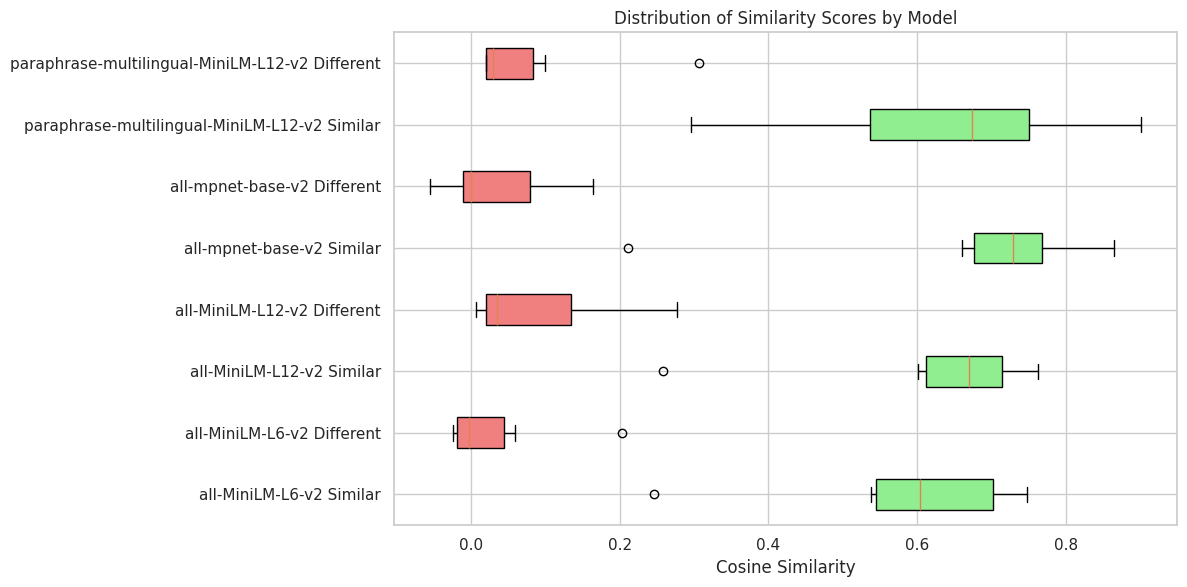

In [17]:
# Visualize the results - Boxplot comparison
plt.figure(figsize=(12, 6))
# Prepare data for boxplot
boxplot_data = []
model_names = []

for model_data in results:
    boxplot_data.append(model_data['Similar Scores'])
    boxplot_data.append(model_data['Dissimilar Scores'])
    model_names.append(f"{model_data['Model']} Similar")
    model_names.append(f"{model_data['Model']} Different")

# Create a color map for the boxes
colors = ['lightgreen', 'lightcoral'] * len(models)

# Create boxplot
bp = plt.boxplot(boxplot_data, patch_artist=True, vert=False)
plt.yticks(range(1, len(model_names) + 1), model_names)
plt.xlabel('Cosine Similarity')
plt.title('Distribution of Similarity Scores by Model')

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    
plt.tight_layout()
plt.show()


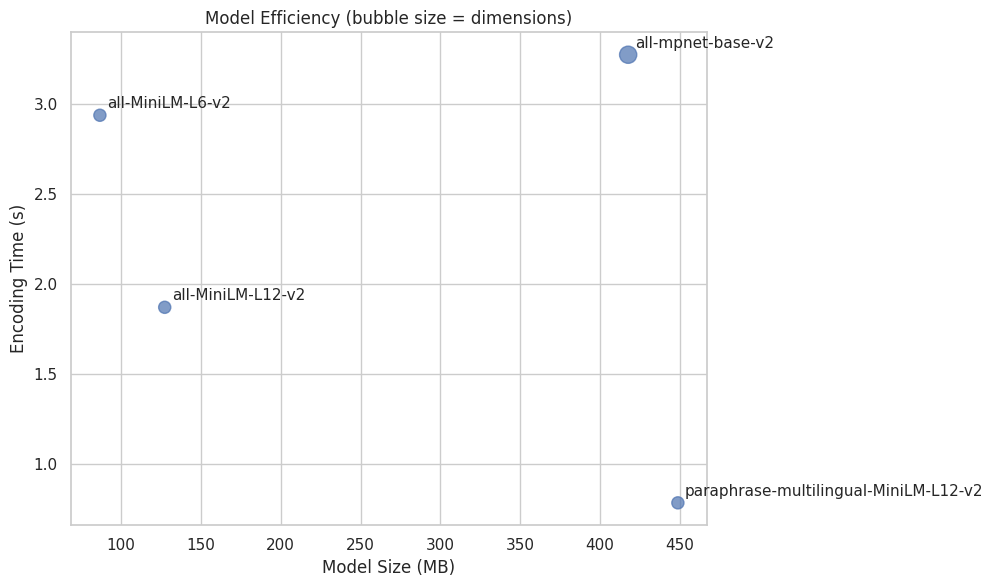

In [20]:
# Visualize the results - Efficiency metrics
plt.figure(figsize=(10, 6))
plt.scatter(df['Size (MB)'], df['Encoding Time (s)'],
            s=df['Dimensions']/5, alpha=0.7)
for i, model in enumerate(df['Model']):
    plt.annotate(model, (df['Size (MB)'].iloc[i], df['Encoding Time (s)'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel('Model Size (MB)')
plt.ylabel('Encoding Time (s)')
plt.title('Model Efficiency (bubble size = dimensions)')
plt.grid(True)
plt.tight_layout()
plt.show()

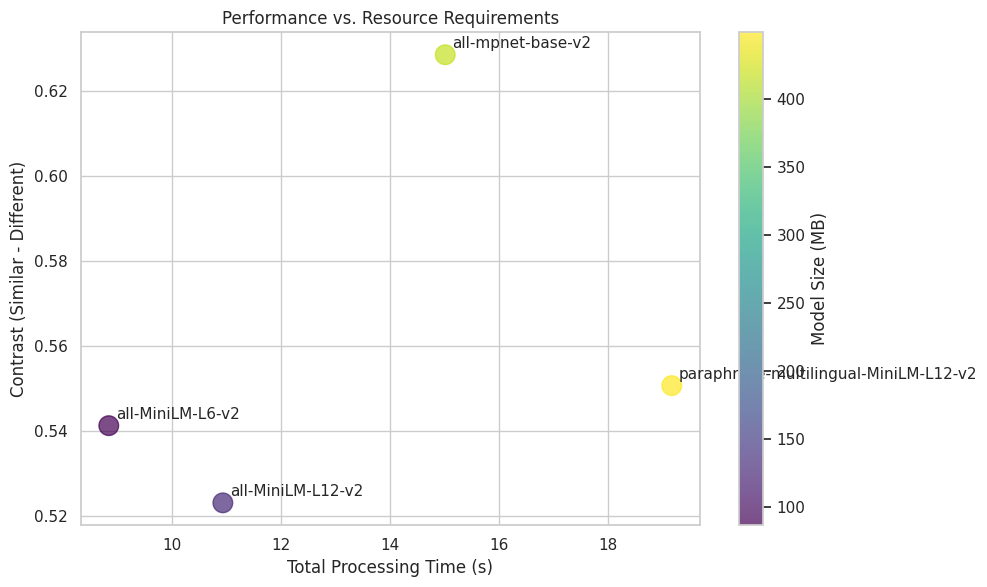

In [21]:
# Visualize the results - Performance vs Resources
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Total Time (s)'], df['Contrast'], c=df['Size (MB)'],
                 s=200, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Model Size (MB)')

for i, model in enumerate(df['Model']):
    plt.annotate(model, (df['Total Time (s)'].iloc[i], df['Contrast'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel('Total Processing Time (s)')
plt.ylabel('Contrast (Similar - Different)')
plt.title('Performance vs. Resource Requirements')
plt.grid(True)
plt.tight_layout()
plt.show()

# Takeaways

- Contrast is king: The contrast score is often the most important metric. A model with higher contrast will be better at distinguishing relevant from irrelevant information.
- Consider the trade-offs: Larger models typically have better semantic understanding but require more resources and run slower. Ask yourself what's more important for your application: accuracy or speed?
- Test with domain-specific data: While our comparison uses general examples, you'll get the best results by testing with examples from your specific domain.
- Think about your constraints: If you're deploying on mobile or edge devices, model size matters more. For server applications, you might prioritize accuracy.
- Consider multilingual needs: If your application needs to work across languages, a multilingual model might be essential even if it's not the top performer in English.
